In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
R = 100          # ohms
L = 50e-3        # henries
C = 10e-6        # farads

Is = 10          # step current source (A)


In [3]:
def parallel_rlc(t, x):
    iL = x[0]      # inductor current
    diL = x[1]     # derivative of inductor current
    
    # Second derivative from the differential equation
    d2iL = (Is - iL - (L/R)*diL) / (L*C)
    
    return [diL, d2iL]


In [9]:
t_span = (0, 0.01)
t_eval = np.linspace(t_span[0], t_span[1], 2000)

x0 = [0, 0]   # iL(0)=0, diL/dt(0)=0

solution = solve_ivp(parallel_rlc, t_span, x0, t_eval=t_eval) # solve intial value problem


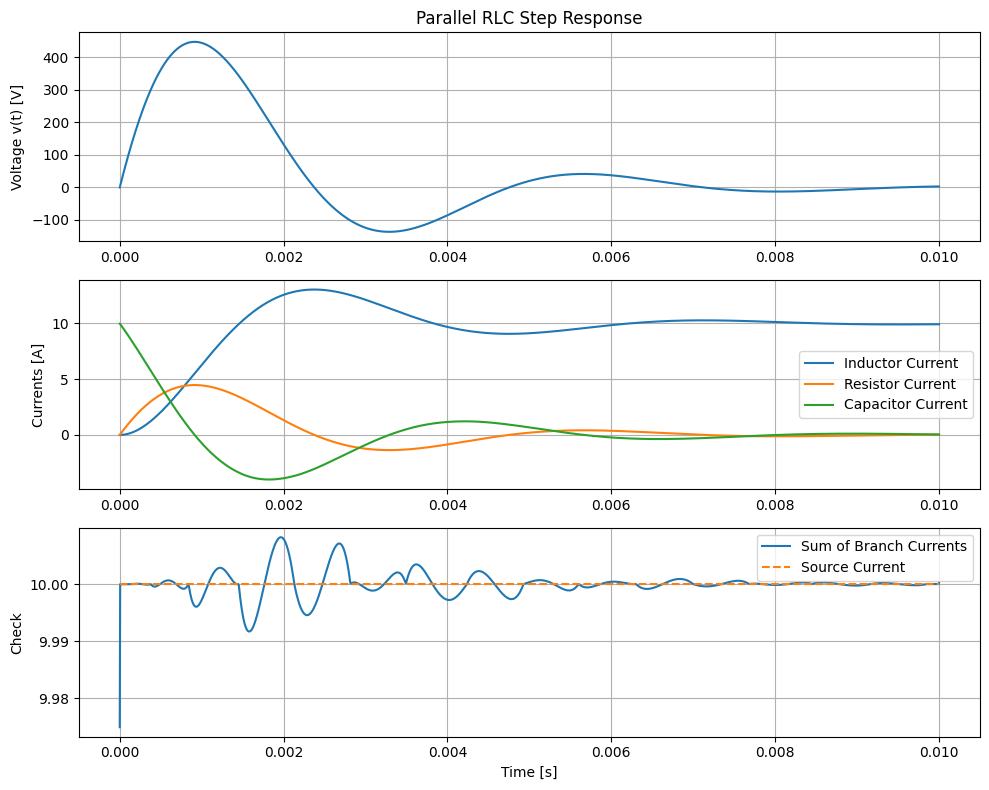

In [10]:
iL = solution.y[0]
diL = solution.y[1]
t = solution.t

v = L * diL
iR = v / R
iC = C * np.gradient(v, t)

plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
plt.plot(t, v)
plt.title("Parallel RLC Step Response")
plt.ylabel("Voltage v(t) [V]")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(t, iL, label="Inductor Current")
plt.plot(t, iR, label="Resistor Current")
plt.plot(t, iC, label="Capacitor Current")
plt.ylabel("Currents [A]")
plt.legend()
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(t, iL + iR + iC, label="Sum of Branch Currents")
plt.plot(t, Is*np.ones_like(t), '--', label="Source Current")
plt.ylabel("Check")
plt.xlabel("Time [s]")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

The parallel RLC:
- The voltage oscillates with its own damping ratio.
- The inductor current tends to dominate early behavior.
- The capacitor current spikes sharply at the start.
- The resistor current damps the oscillation.
